   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


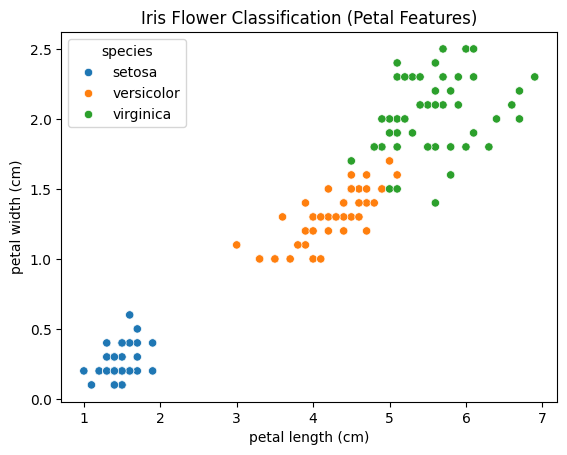

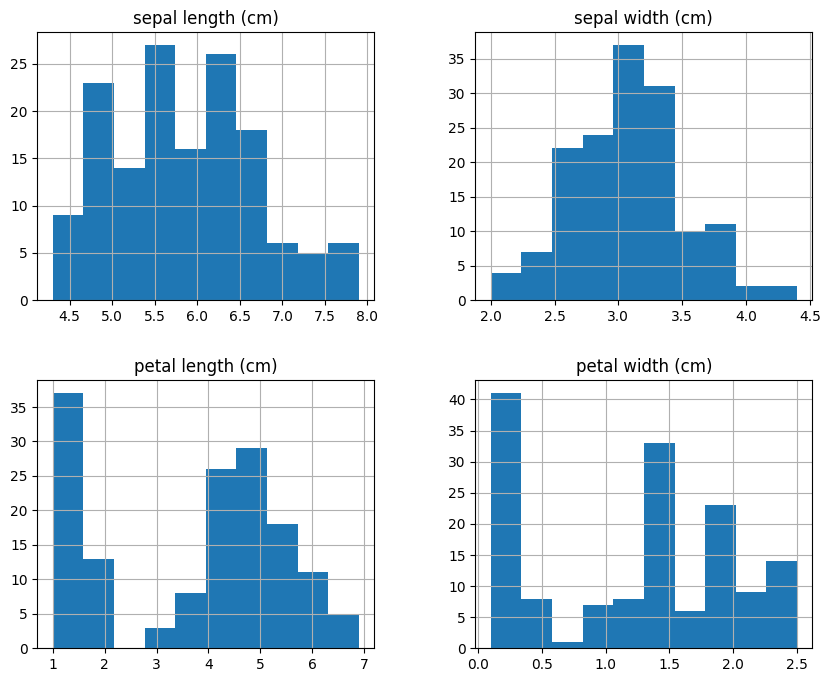

Accuracy: 1.0


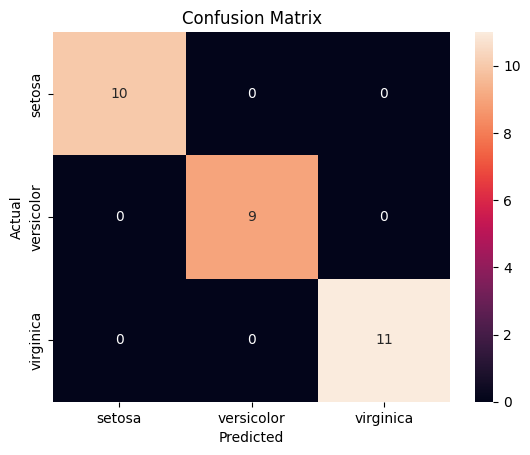


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- Predict New Flower ---
Predicted Iris Species: virginica


c:\Users\WINDOWS11\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
#1. Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Load Iris Dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species column
df['species'] = iris.target
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print(df.head())

# 3. Data Visualization

# Scatter plot
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    data=df
)
plt.title("Iris Flower Classification (Petal Features)")
plt.show()

# Histogram
df.hist(figsize=(10, 8))
plt.show()


# 4. Train-Test Split
X = df.iloc[:, :-1]   # features
y = df['species']    # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Model (Logistic Regression)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


# 6. Prediction
y_pred = model.predict(X_test)

# 7. Model Evaluation
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 8. User Input Prediction (Optional)
print("\n--- Predict New Flower ---")
sl = float(input("Enter sepal length (cm): "))
sw = float(input("Enter sepal width (cm): "))
pl = float(input("Enter petal length (cm): "))
pw = float(input("Enter petal width (cm): "))

new_data = [[sl, sw, pl, pw]]
prediction = model.predict(new_data)

print("Predicted Iris Species:", prediction[0])